<a href="https://colab.research.google.com/github/jothimani7806/movie_gerne_prediction/blob/main/Movie_Genere_Clasiffication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Import libraries

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Step 2: Load and parse the data

In [ ]:
def load_labeled(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) == 4:
                rows.append(parts)
    return pd.DataFrame(rows, columns=['id', 'title', 'genre', 'description'])

def load_unlabeled(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) == 3:
                rows.append(parts)
    return pd.DataFrame(rows, columns=['id', 'title', 'description'])

train_df = load_labeled('/content/drive/MyDrive/Colab Notebooks/train_data.txt')
test_df = load_unlabeled('/content/drive/MyDrive/Colab Notebooks/test_data.txt')
solution_df = load_labeled('/content/drive/MyDrive/Colab Notebooks/test_data_solution.txt')

print(train_df.shape, test_df.shape, solution_df.shape)
train_df.head()

(54214, 4) (54200, 3) (54200, 4)


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


# Step 3: Explore the data

In [ ]:
print(train_df['genre'].value_counts())

genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64


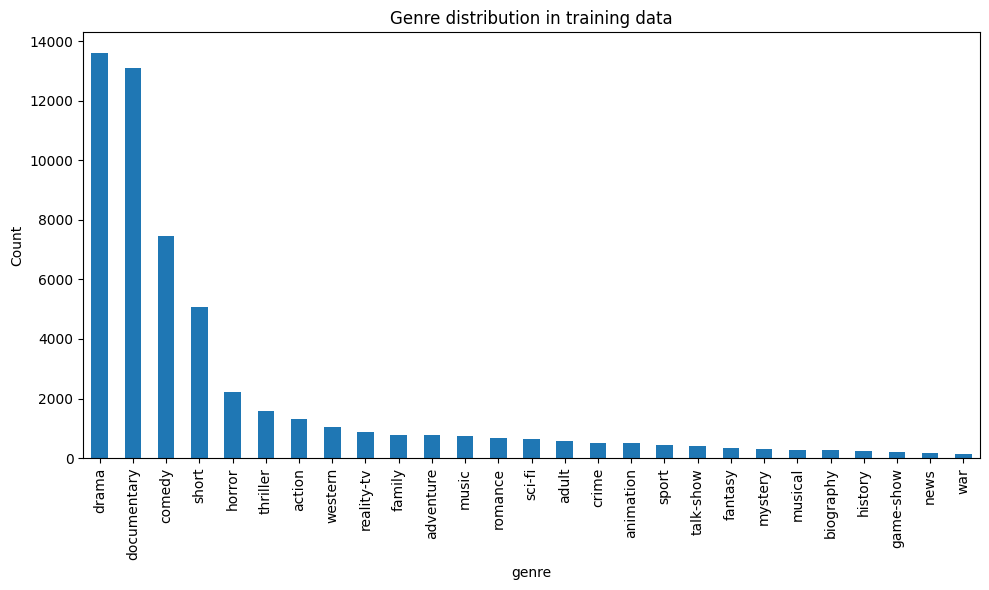

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
train_df['genre'].value_counts().plot(kind='bar')
plt.title('Genre distribution in training data')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Step 4: Clean the text

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', ' ', text)        # remove bracketed notes
    text = re.sub(r'http\S+|www\S+', ' ', text)  # remove urls
    text = re.sub(r'[^a-z\s]', ' ', text)        # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(words)

train_df['clean_description'] = train_df['description'].apply(clean_text)
test_df['clean_description'] = test_df['description'].apply(clean_text)
solution_df['clean_description'] = solution_df['description'].apply(clean_text)

# Step 5: Encode genre labels as numbers

Models need numeric targets, not strings.

In [ ]:
le = LabelEncoder()
train_df['genre_encoded'] = le.fit_transform(train_df['genre'])
print(dict(zip(le.classes_, range(len(le.classes_)))))

{'action': 0, 'adult': 1, 'adventure': 2, 'animation': 3, 'biography': 4, 'comedy': 5, 'crime': 6, 'documentary': 7, 'drama': 8, 'family': 9, 'fantasy': 10, 'game-show': 11, 'history': 12, 'horror': 13, 'music': 14, 'musical': 15, 'mystery': 16, 'news': 17, 'reality-tv': 18, 'romance': 19, 'sci-fi': 20, 'short': 21, 'sport': 22, 'talk-show': 23, 'thriller': 24, 'war': 25, 'western': 26}


# Step 6: Split off a validation set

We hold out part of train_data.txt to test different models before touching the real test set.  

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['clean_description'],
    train_df['genre_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['genre_encoded']
)

# Step 7: Convert text to numbers with TF-IDF

In [ ]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

# Step 8: Train and compare three classifiers

In [ ]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Linear SVM': LinearSVC(class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_val_tfidf)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')
    print(f"{name}: accuracy={acc:.4f}  macro-F1={f1:.4f}")

Naive Bayes: accuracy=0.5002  macro-F1=0.0984
Logistic Regression: accuracy=0.4974  macro-F1=0.3729
Linear SVM: accuracy=0.5429  macro-F1=0.3655


# Step 9: Inspect the best model closely

In [ ]:
best_model = LogisticRegression(max_iter=1000, class_weight='balanced')  # swap in your actual winner
best_model.fit(X_train_tfidf, y_train)
val_preds = best_model.predict(X_val_tfidf)

print(classification_report(y_val, val_preds, target_names=le.classes_))

              precision    recall  f1-score   support

      action       0.34      0.51      0.41       263
       adult       0.42      0.75      0.53       118
   adventure       0.21      0.33      0.26       155
   animation       0.20      0.30      0.24       100
   biography       0.04      0.08      0.05        53
      comedy       0.62      0.47      0.53      1490
       crime       0.15      0.34      0.21       101
 documentary       0.79      0.62      0.69      2619
       drama       0.71      0.40      0.51      2723
      family       0.15      0.31      0.20       157
     fantasy       0.12      0.20      0.15        65
   game-show       0.70      0.72      0.71        39
     history       0.10      0.29      0.15        49
      horror       0.58      0.71      0.64       441
       music       0.39      0.79      0.52       146
     musical       0.12      0.20      0.15        55
     mystery       0.11      0.17      0.14        64
        news       0.16    

visualize the confusion matrix to see which genres get mixed up with each other (commonly thriller/horror/crime):

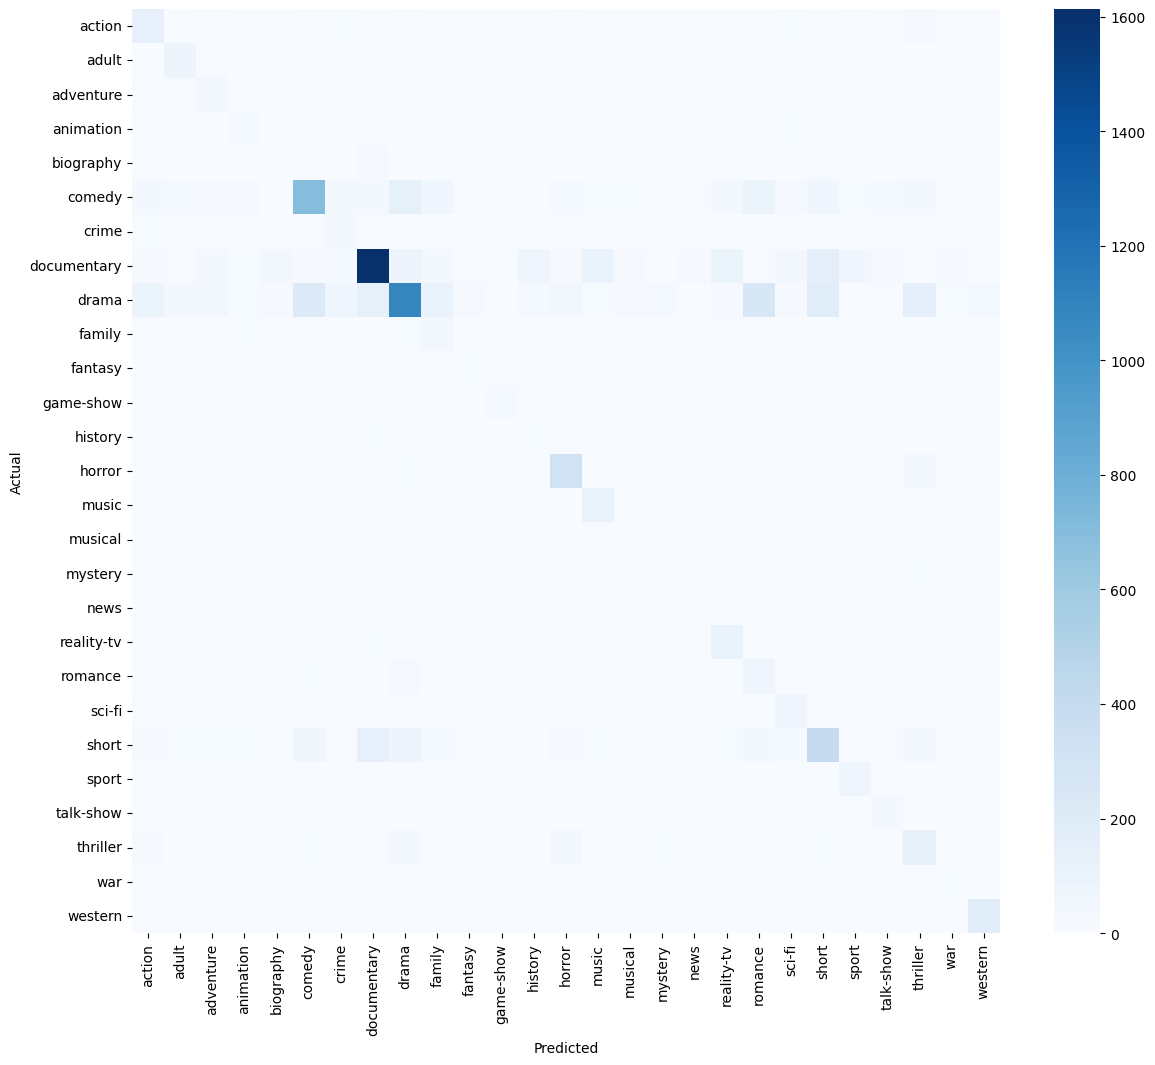

In [ ]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 10 (optional): Tune hyperparameters



In [ ]:
param_grid = {'C': [0.1, 1, 10]}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid, scoring='f1_macro', cv=3
)
grid.fit(X_train_tfidf, y_train)
print(grid.best_params_, grid.best_score_)

{'C': 10} 0.38869684476036226


# Step 11: Retrain on all training data, then score on the real test set

This is the moment of truth — predict on test_data.txt and check against the true genres in test_data_solution.txt.

In [ ]:
# Re-fit TF-IDF and the model on the FULL training set (not just the 80% split)
X_full_tfidf = tfidf.fit_transform(train_df['clean_description'])
y_full = train_df['genre_encoded']

final_model = LogisticRegression(max_iter=1000, class_weight='balanced', C=grid.best_params_['C'])
final_model.fit(X_full_tfidf, y_full)

X_test_tfidf = tfidf.transform(test_df['clean_description'])
test_preds = final_model.predict(X_test_tfidf)
test_df['predicted_genre'] = le.inverse_transform(test_preds)

# Compare against the ground truth
true_genres = solution_df['genre'].values
pred_genres = test_df['predicted_genre'].values

print("Test Accuracy:", accuracy_score(true_genres, pred_genres))
print("Test Macro F1:", f1_score(true_genres, pred_genres, average='macro'))
print(classification_report(true_genres, pred_genres))

Test Accuracy: 0.5652029520295203
Test Macro F1: 0.4029279643742844
              precision    recall  f1-score   support

      action       0.36      0.48      0.41      1314
       adult       0.50      0.56      0.53       590
   adventure       0.30      0.32      0.31       775
   animation       0.28      0.25      0.26       498
   biography       0.08      0.06      0.07       264
      comedy       0.58      0.58      0.58      7446
       crime       0.20      0.25      0.22       505
 documentary       0.78      0.72      0.75     13096
       drama       0.68      0.56      0.61     13612
      family       0.22      0.26      0.24       783
     fantasy       0.21      0.18      0.20       322
   game-show       0.77      0.73      0.74       193
     history       0.11      0.09      0.10       243
      horror       0.59      0.66      0.62      2204
       music       0.50      0.67      0.57       731
     musical       0.23      0.23      0.23       276
     mystery 

# Step 12: Save the model so you don't have to retrain it next time



In [ ]:
import joblib
from google.colab import files

joblib.dump(final_model, 'genre_classifier.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

files.download('genre_classifier.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 13: Use it on a brand-new description

In [ ]:
def predict_genre(description):
    cleaned = clean_text(description)
    vec = tfidf.transform([cleaned])
    pred = final_model.predict(vec)
    return le.inverse_transform(pred)[0]

predict_genre("Avengers")

'short'

In [ ]:
!pip install -q gradio

import gradio as gr

def predict_genre_gradio(description):
    cleaned = clean_text(description)
    vec = tfidf.transform([cleaned])
    pred = final_model.predict(vec)
    return le.inverse_transform(pred)[0]

demo = gr.Interface(
    fn=predict_genre_gradio,
    inputs=gr.Textbox(lines=5, placeholder="Paste a movie plot description here..."),
    outputs=gr.Textbox(label="Predicted Genre"),
    title="Movie Genre Classifier",
    description="Enter a movie plot summary to predict its genre."
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ee4213307d8feaa0a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
